# Tech Challenge — Fase 1
## Sistema de Suporte ao Diagnóstico: Detecção de Câncer de Mama com Machine Learning

**FIAP — Pós Tech (IA para Devs - 11IADT)**

### Sumário
1. [Dataset](#contexto)
2. [Carga dos Dados](#carga)
3. [Exploração de Dados (EDA)](#eda)
4. [Pré-processamento](#preprocessamento)
5. [Análise de Correlação](#correlacao)
6. [Modelagem](#modelagem)
7. [Treinamento e Avaliação](#avaliacao)
8. [Explicabilidade (Feature Importance & SHAP)](#explicabilidade)


<a name="contexto"></a>
## 1. Dataset

**Dataset escolhido:** [Breast Cancer Wisconsin (Diagnostic) Data Set](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data)
— o arquivo `data.csv` já está incluído neste repositório (pasta deste notebook), então não é
necessário nenhuma credencial ou download manual para rodar o notebook.


<a name="carga"></a>
## 2. Carga dos Dados

O carregamento assume que `data.csv` está na mesma pasta do notebook (é o caso se você abrir
este notebook a partir do repositório clonado/baixado). Se estiver rodando no Colab **sem**
clonar o repositório, a célula de carga detecta a ausência do arquivo e oferece upload manual.


In [ ]:
# Instalação de dependências (necessário apenas na primeira execução no Colab)
!pip install -q shap


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, roc_auc_score
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42


In [ ]:
DATA_PATH = "data.csv"

# Se o CSV não estiver na pasta local (ex.: notebook aberto isoladamente no Colab, sem
# clonar o repositório), oferece upload manual como alternativa.
if not os.path.exists(DATA_PATH):
    try:
        from google.colab import files
        print(f"'{DATA_PATH}' não encontrado localmente. Faça upload do arquivo data.csv:")
        uploaded = files.upload()
        (fname, content), = uploaded.items()
        with open(DATA_PATH, "wb") as f:
            f.write(content)
    except ImportError:
        raise FileNotFoundError(
            f"'{DATA_PATH}' não encontrado. Coloque o arquivo data.csv na mesma pasta "
            "deste notebook (baixado de https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)."
        )

df = pd.read_csv(DATA_PATH)

# Remove colunas que não são features (identificador do paciente e a coluna vazia que o
# CSV original do Kaggle traz por causa de uma vírgula final no cabeçalho)
df.drop(columns=["id", "Unnamed: 32"], errors="ignore", inplace=True)

# diagnosis vem como "M"/"B" no arquivo original — mapeamos para um alvo numérico
# (0 = malignant, 1 = benign) e mantemos também um rótulo textual para os gráficos
df["diagnosis"] = df["diagnosis"].map({"M": 0, "B": 1})
df["diagnosis_label"] = df["diagnosis"].map({0: "malignant", 1: "benign"})

print(f"Formato do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()


Formato do dataset: 569 linhas x 32 colunas


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_label
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,0,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,0,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,0,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,0,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


<a name="eda"></a>
## 3. Exploração de Dados (EDA)


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [ ]:
# Estatísticas descritivas das features
df.describe().T


,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.627417,0.483918,0.000000,0.000000,1.000000,1.000000,1.00000
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400


In [ ]:
# Valores ausentes
missing = df.isnull().sum()
print("Valores ausentes por coluna:")
print(missing[missing > 0] if missing.sum() > 0 else "Nenhum valor ausente encontrado.")


Valores ausentes por coluna:
Nenhum valor ausente encontrado.


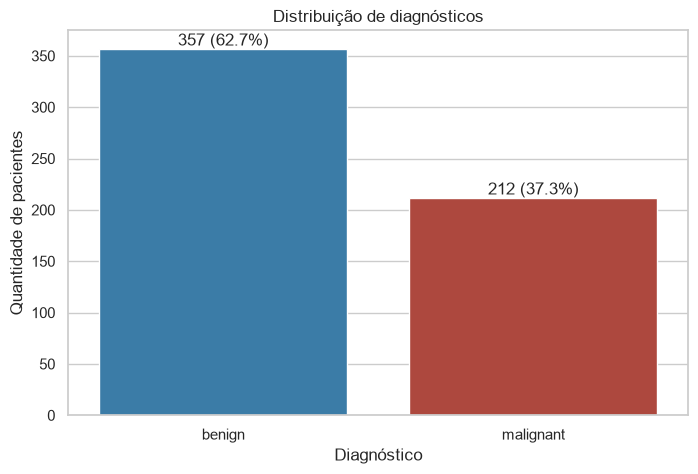

diagnosis_label
benign       357
malignant    212
Name: count, dtype: int64


In [ ]:
# Distribuição da variável alvo (balanceamento de classes)
counts = df["diagnosis_label"].value_counts()
pct = df["diagnosis_label"].value_counts(normalize=True) * 100

fig, ax = plt.subplots()
sns.countplot(data=df, x="diagnosis_label", order=counts.index, hue="diagnosis_label",
              hue_order=counts.index,
              palette={"malignant": "#c0392b", "benign": "#2980b9"}, legend=False, ax=ax)
ax.set_title("Distribuição de diagnósticos")
ax.set_xlabel("Diagnóstico")
ax.set_ylabel("Quantidade de pacientes")
for i, v in enumerate(counts):
    ax.text(i, v + 3, f"{v} ({pct[counts.index[i]]:.1f}%)", ha="center")
plt.show()

print(counts)


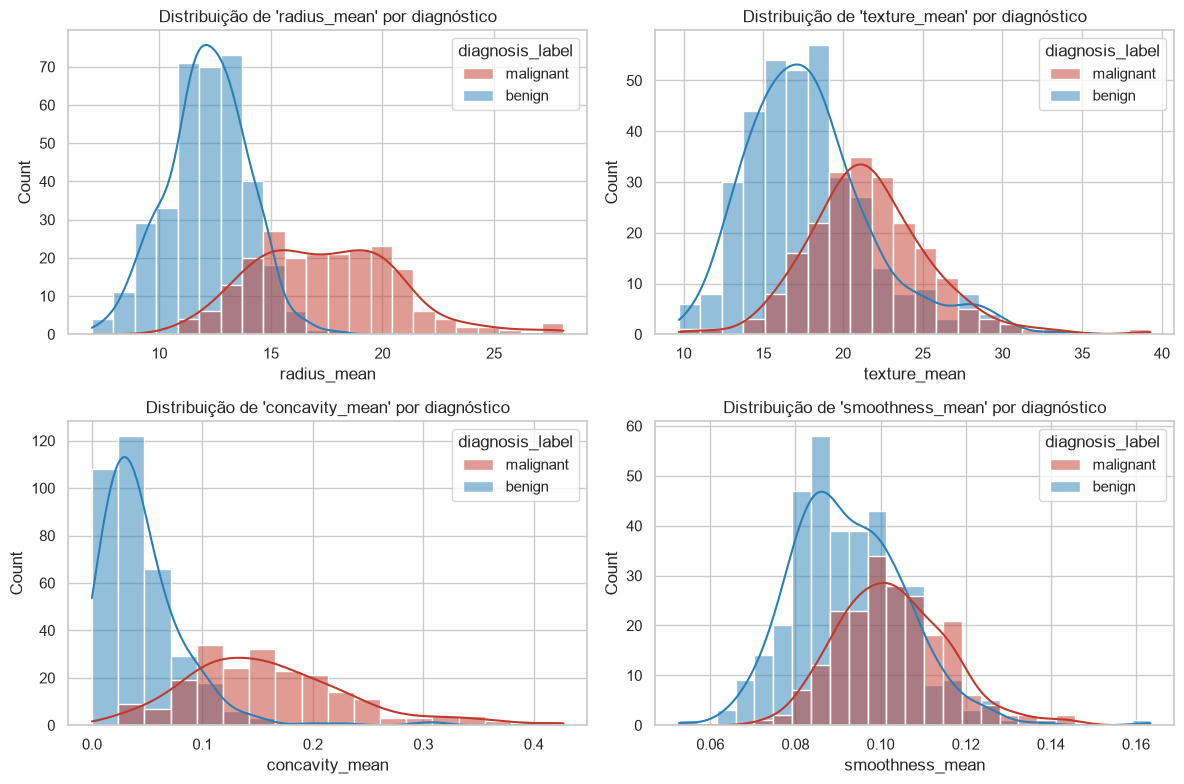

In [ ]:
# Distribuições de features-chave por diagnóstico
key_features = ["radius_mean", "texture_mean", "concavity_mean", "smoothness_mean"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.ravel(), key_features):
    sns.histplot(data=df, x=feat, hue="diagnosis_label", kde=True,
                 palette={"malignant": "#c0392b", "benign": "#2980b9"}, ax=ax, alpha=0.5)
    ax.set_title(f"Distribuição de '{feat}' por diagnóstico")
plt.tight_layout()
plt.show()


**Padrões observados:** tumores malignos tendem a apresentar valores mais altos e com
maior dispersão de `radius_mean`, `concavity_mean` e `texture_mean` — consistente com a
literatura clínica, onde massas malignas costumam ser maiores e com bordas mais irregulares
(maior concavidade). Isso já indica que essas variáveis devem ter forte poder preditivo.


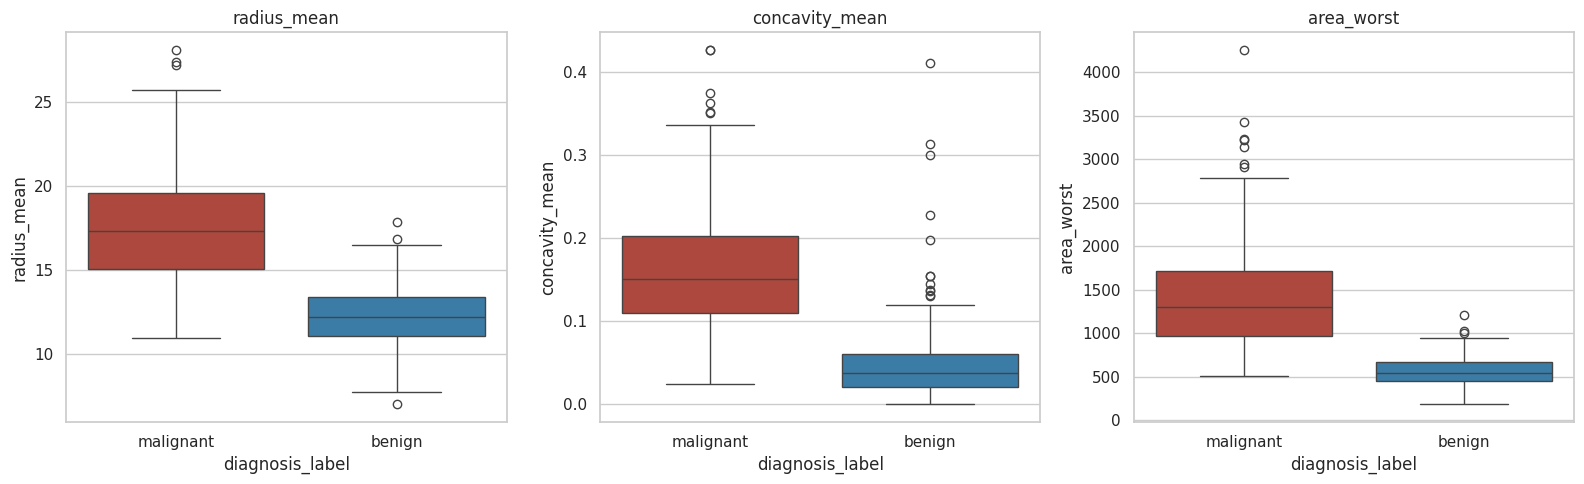

In [ ]:
# Boxplots para visualizar dispersão e outliers por classe
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, ["radius_mean", "concavity_mean", "area_worst"]):
    sns.boxplot(data=df, x="diagnosis_label", y=feat, hue="diagnosis_label",
                palette={"malignant": "#c0392b", "benign": "#2980b9"}, legend=False, ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.show()


<a name="preprocessamento"></a>
## 4. Pré-processamento de Dados


In [ ]:
feature_cols = [c for c in df.columns if c not in ("diagnosis", "diagnosis_label")]
X = df[feature_cols]
y = df["diagnosis"]  # 0 = malignant, 1 = benign

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")
print("\nProporção de classes no treino:")
print(y_train.value_counts(normalize=True))
print("\nProporção de classes no teste:")
print(y_test.value_counts(normalize=True))


Treino: 455 amostras | Teste: 114 amostras

Proporção de classes no treino:
diagnosis
1    0.626374
0    0.373626
Name: proportion, dtype: float64

Proporção de classes no teste:
diagnosis
1    0.631579
0    0.368421
Name: proportion, dtype: float64


In [ ]:
# Pipeline de pré-processamento (padronização das features numéricas)
# Estruturado com ColumnTransformer para facilitar extensão a variáveis categóricas futuras.
from sklearn.compose import ColumnTransformer

numeric_features = feature_cols  # todas as colunas são numéricas neste dataset
categorical_features = []  # nenhuma variável categórica presente

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
])

preprocessor


ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['radius_mean', 'texture_mean',
                                  'perimeter_mean', 'area_mean',
                                  'smoothness_mean', 'compactness_mean',
                                  'concavity_mean', 'concave points_mean',
                                  'symmetry_mean', 'fractal_dimension_mean',
                                  'radius_se', 'texture_se', 'perimeter_se',
                                  'area_se', 'smoothness_se', 'compactness_se',
                                  'concavity_se', 'concave points_se',
                                  'symmetry_se', 'fractal_dimension_se',
                                  'radius_worst', 'texture_worst',
                                  'perimeter_worst', 'area_worst',
                                  'smoothness_worst', 'compactness_worst',
                                  'concavity_worst', 'concave points_worst',
                                  'symmetry_worst',
                                  'fractal_dimension_worst'])])

<a name="correlacao"></a>
## 5. Análise de Correlação


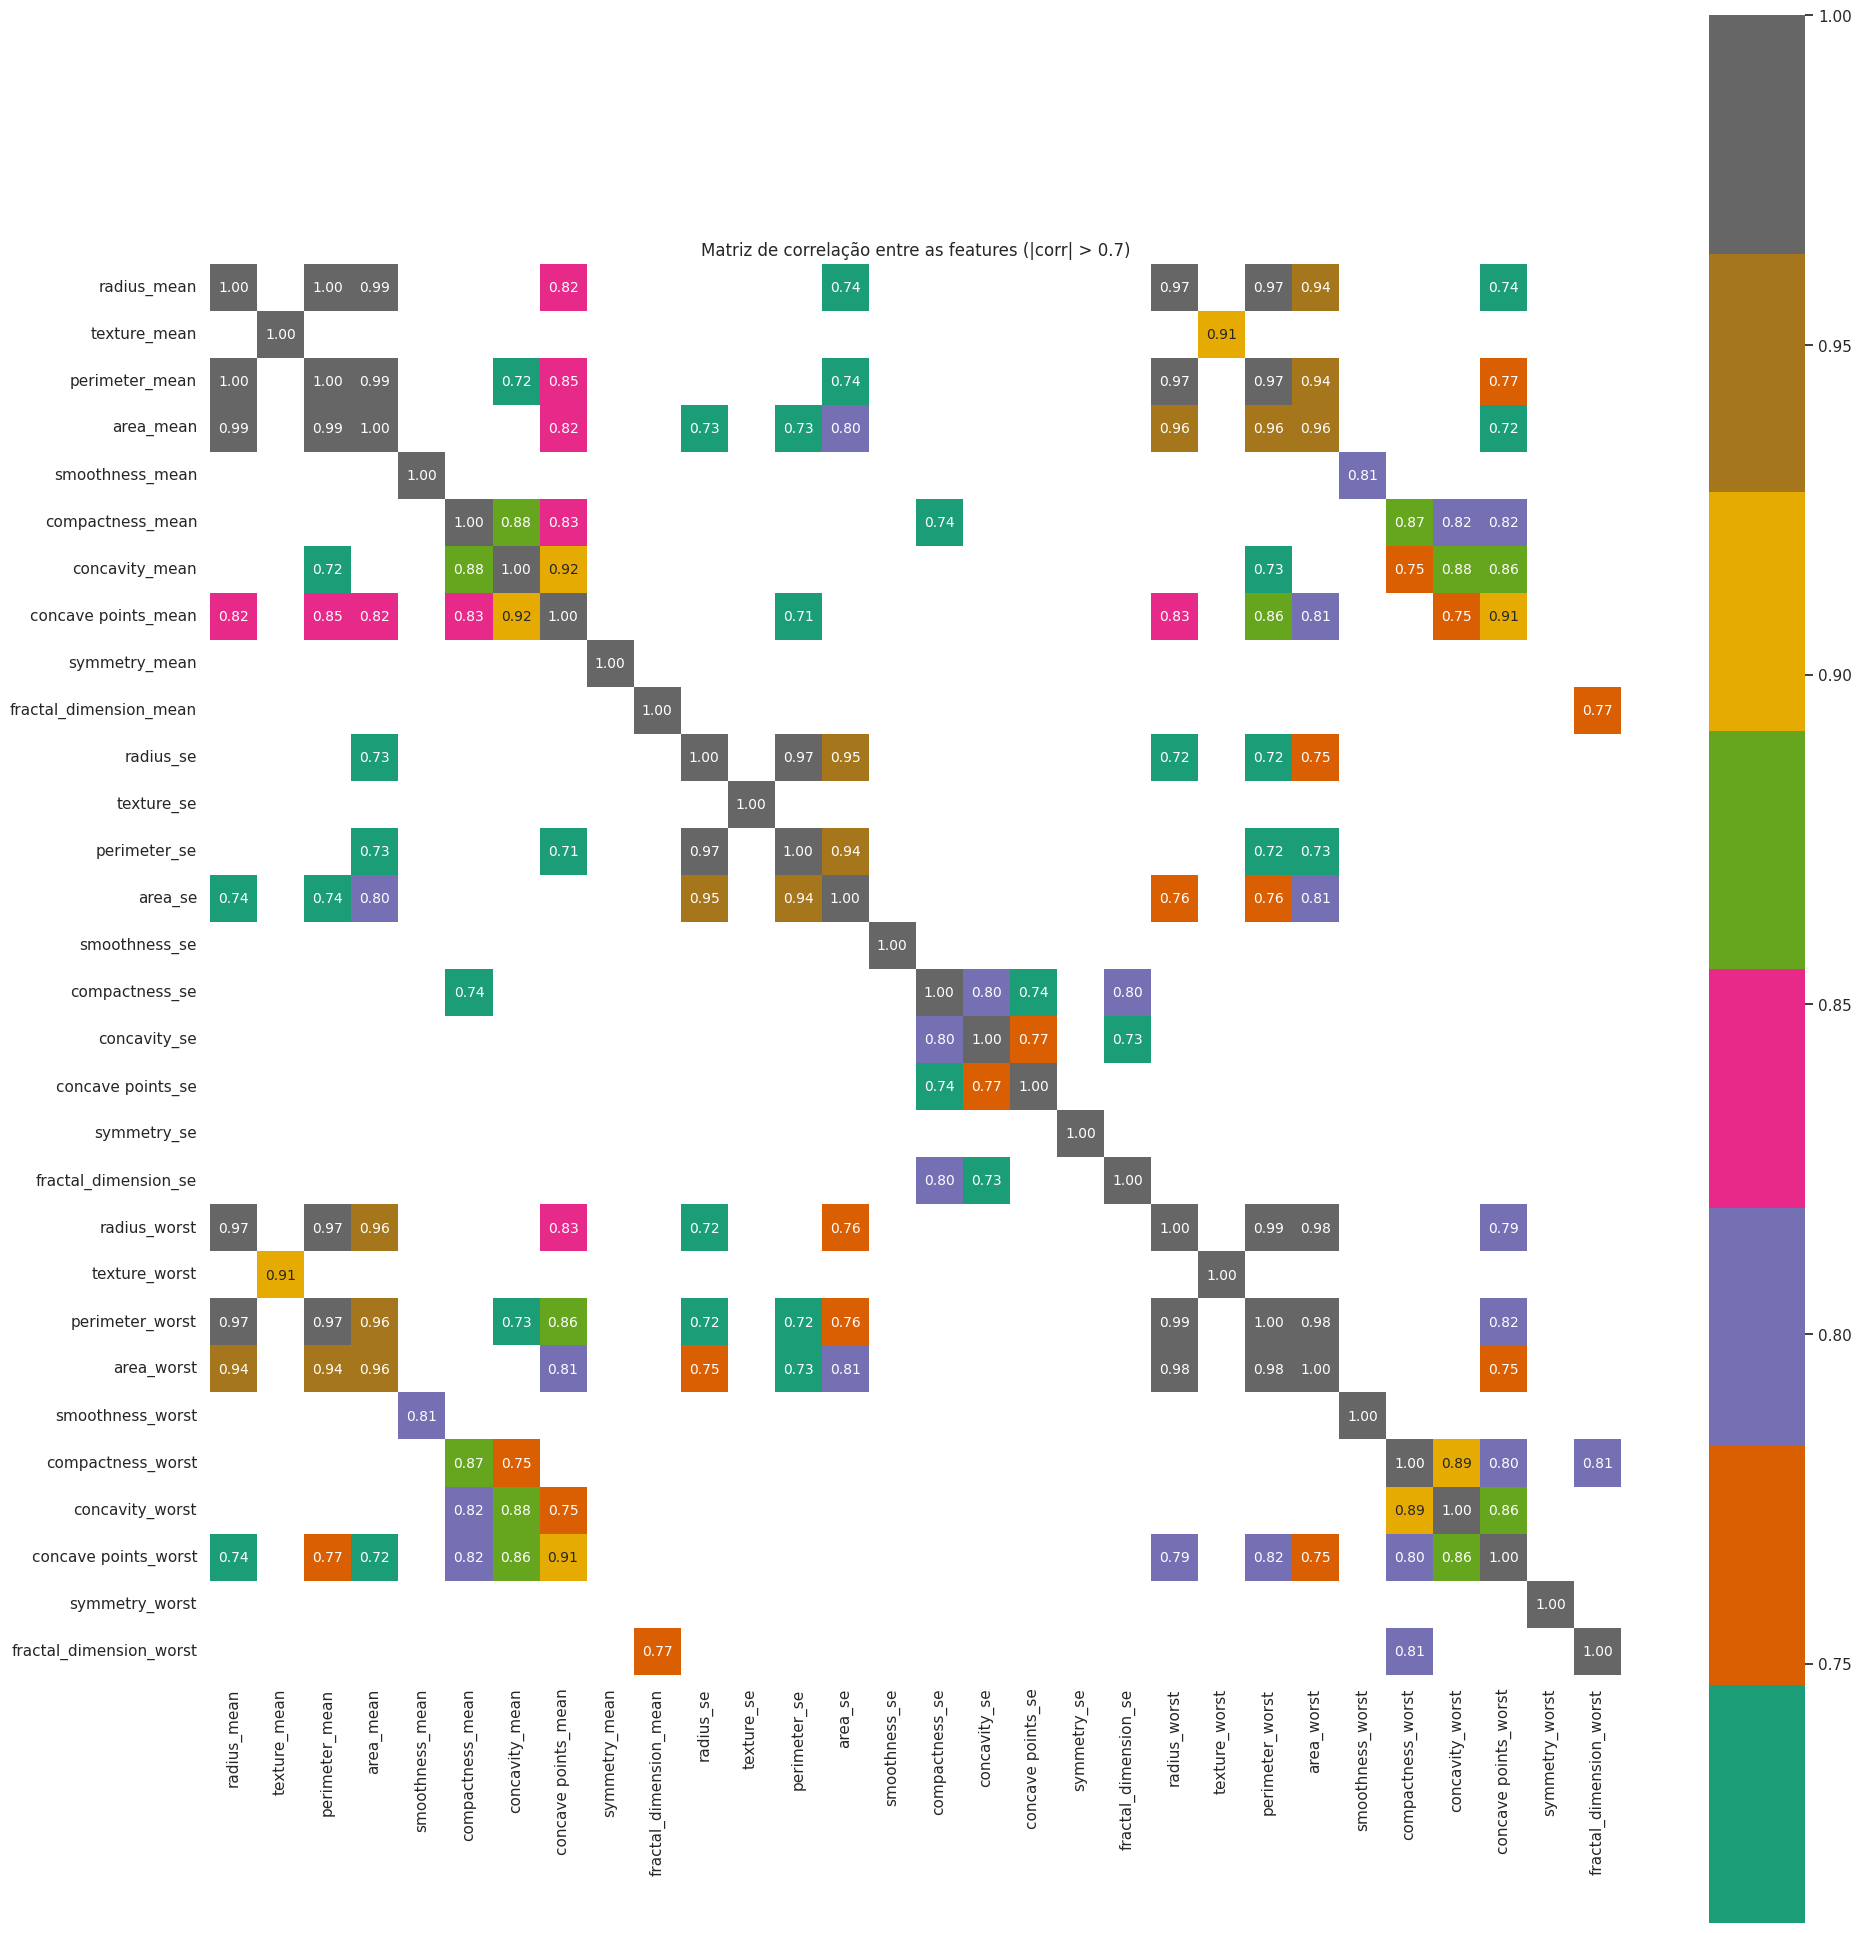

In [ ]:
corr = X.corr()

# Mantém apenas correlações fortes (|corr| > 0.7), o resto vira NaN
strong_corr = corr[abs(corr) > 0.7]

fig, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(
    strong_corr,
    cbar=True,
    annot=True,
    square=True,
    fmt='.2f',
    annot_kws={'size': 10},
    yticklabels=corr.columns,
    xticklabels=corr.columns,
    cmap='Dark2',
    ax=ax
)
ax.set_title("Matriz de correlação entre as features (|corr| > 0.7)")
plt.tight_layout()
plt.show()



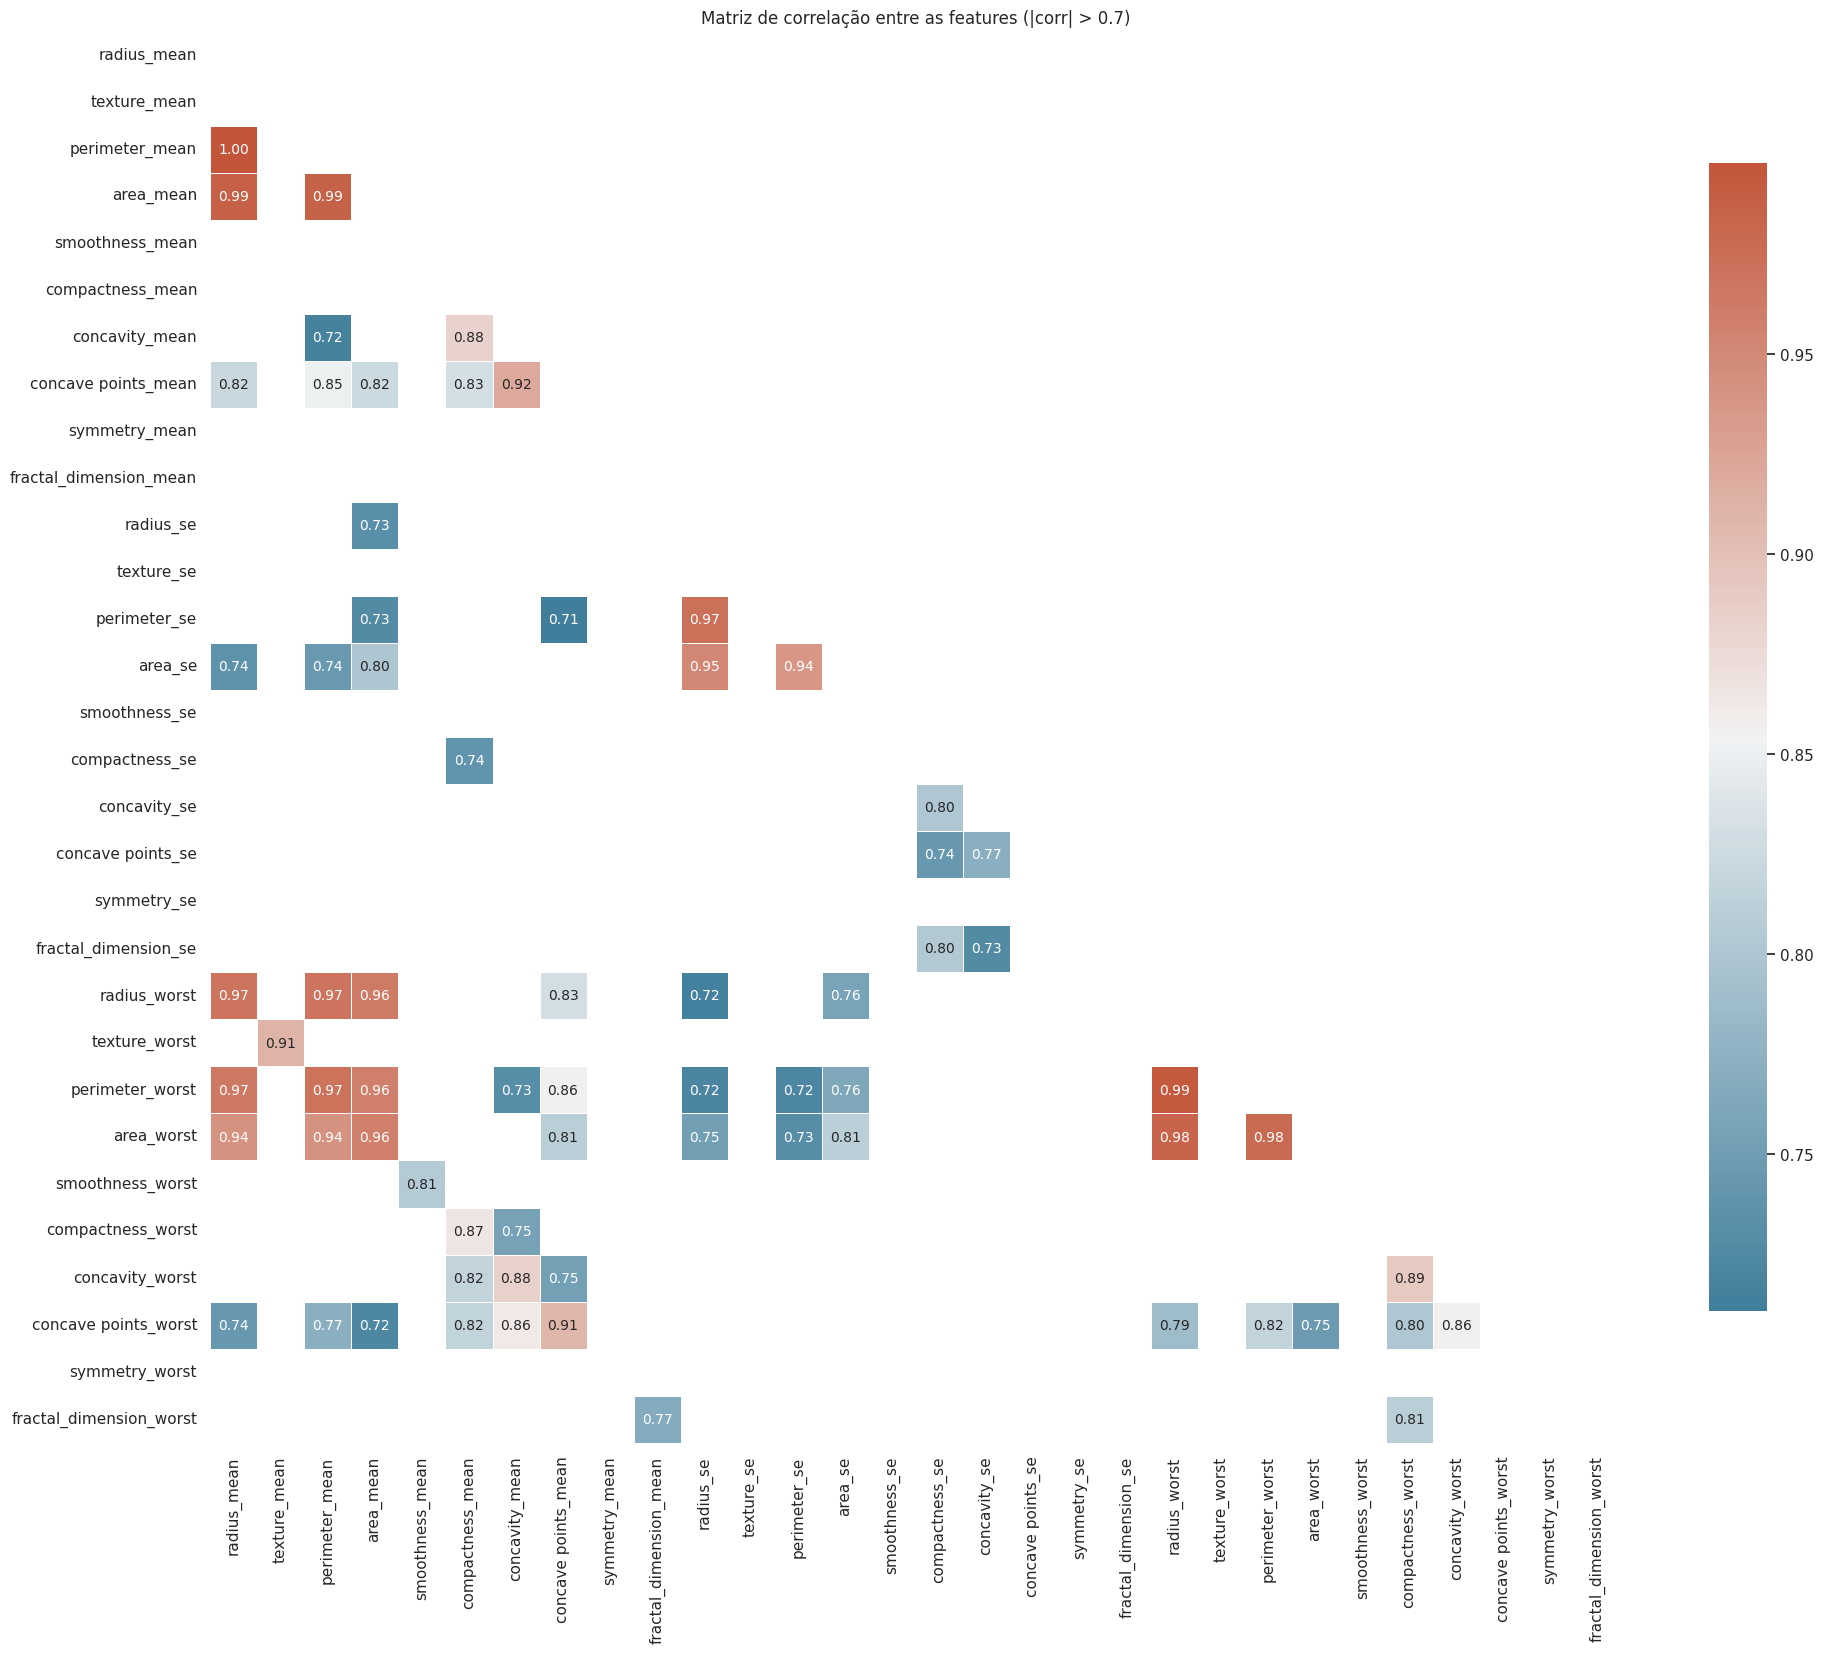

In [ ]:
sns.set_theme(style="white")

corr = X.corr()

# Mantém apenas correlações fortes (|corr| > 0.7), o resto vira NaN
strong_corr = corr[abs(corr) > 0.7]

# Máscara para exibir apenas o triângulo inferior
mask = np.triu(np.ones_like(strong_corr, dtype=bool))

# Colormap divergente customizado
cmap = sns.diverging_palette(230, 20, as_cmap=True)

fig, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(
    strong_corr,
    mask=mask,
    cmap=cmap,
    square=True,
    linewidths=.5,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 10},
    yticklabels=corr.columns,
    xticklabels=corr.columns,
    cbar_kws={"shrink": .6},
    ax=ax
)
ax.set_title("Matriz de correlação entre as features (|corr| > 0.7)")
plt.tight_layout()
plt.show()

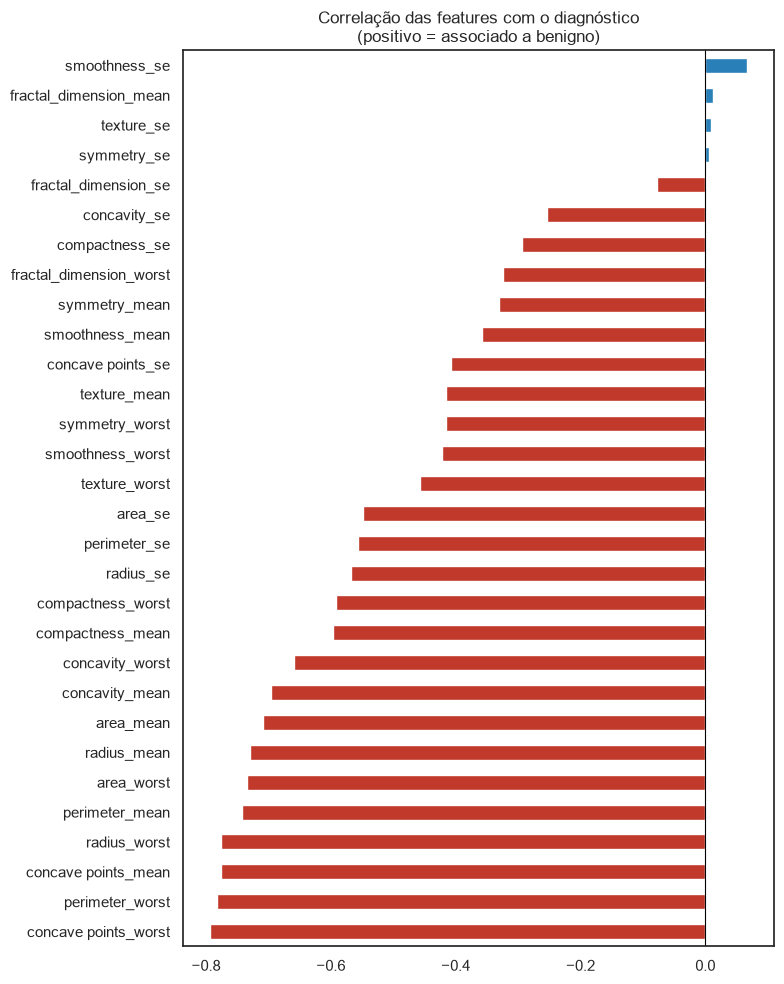

Top 5 features mais correlacionadas (em módulo) com o diagnóstico:
concave points_worst   -0.793566
perimeter_worst        -0.782914
concave points_mean    -0.776614
radius_worst           -0.776454
perimeter_mean         -0.742636
Name: diagnosis, dtype: float64


In [ ]:
# Correlação de cada feature com o diagnóstico (0=maligno, 1=benigno)
corr_target = df[feature_cols + ["diagnosis"]].corr()["diagnosis"].drop("diagnosis").sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
corr_target.plot(kind="barh", ax=ax, color=np.where(corr_target > 0, "#2980b9", "#c0392b"))
ax.set_title("Correlação das features com o diagnóstico\n(positivo = associado a benigno)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print("Top 5 features mais correlacionadas (em módulo) com o diagnóstico:")
print(corr_target.reindex(corr_target.abs().sort_values(ascending=False).index).head())


<a name="modelagem"></a>
## 6. Modelagem

Treinamos **Quatro** algoritmos de classificação para comparação, todos encapsulados em
`Pipeline` (pré-processamento + modelo) para evitar vazamento de dados (*data leakage*) entre
treino e teste:

1. **Regressão Logística** — modelo linear, simples, altamente interpretável (baseline clínico razoável).
2. **Árvore de Decisão** — captura relações não lineares, boa interpretabilidade via regras.
3. **Random Forest** — ensemble robusto, geralmente maior poder preditivo, com feature importance nativa.
4. **Knn** — modelo baseado em distância, classifica cada dos K vizinhos mais próximos.



/tmp/ipykernel_489/1433533642.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


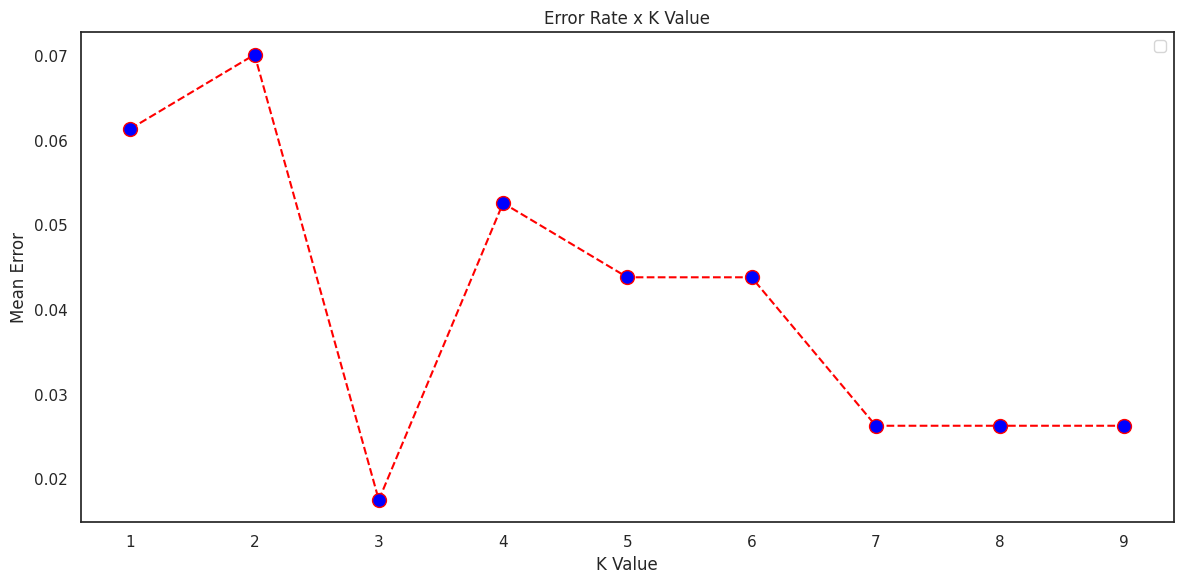

In [ ]:
# Escolha do valor de K para o KNN: taxa de erro no teste, por K
# Como todas as features do dataset são numéricas (ver seção de pré-processamento),
# aplicamos o StandardScaler diretamente em X_train/X_test para este teste de K.
scaler_knn = StandardScaler()
scaler_knn.fit(X_train)

X_train_escalonado = scaler_knn.transform(X_train)
X_test_escalonado = scaler_knn.transform(X_test)

error = []

for i in range(1, 10):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_escalonado, y_train)
    pred_i = knn.predict(X_test_escalonado)
    error.append(np.mean(pred_i != y_test))

plt.figure(figsize=(12, 6))
plt.plot(range(1, 10), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate x K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')
plt.legend()
plt.tight_layout()
plt.show()

melhor_k = list(range(1, 10))[int(np.argmin(error))]

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=3),
}

pipelines = {
    name: Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])
    for name, clf in models.items()
}
pipelines


{'Logistic Regression': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num', StandardScaler(),
                                                   ['radius_mean',
                                                    'texture_mean',
                                                    'perimeter_mean',
                                                    'area_mean',
                                                    'smoothness_mean',
                                                    'compactness_mean',
                                                    'concavity_mean',
                                                    'concave points_mean',
                                                    'symmetry_mean',
                                                    'fractal_dimension_mean',
                                                    'radius_se', 'texture_se',
                                                    'perimeter_se', 'area_se',
    

<a name="avaliacao"></a>
## 7. Treinamento e Avaliação do Modelo



In [ ]:
results = []

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    # Recall/precision/F1 calculados para a classe "malignant" (label 0) — a classe crítica
    results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (malignant)": precision_score(y_test, y_pred, pos_label=0),
        "Recall (malignant)": recall_score(y_test, y_pred, pos_label=0),
        "F1 (malignant)": f1_score(y_test, y_pred, pos_label=0),
    })

results_df = pd.DataFrame(results).set_index("Modelo").sort_values("Recall (malignant)", ascending=False)
results_df.style.format("{:.3f}").background_gradient(cmap="Greens")


,Accuracy,Precision (malignant),Recall (malignant),F1 (malignant)
Modelo,,,,
Logistic Regression,0.982,0.976,0.976,0.976
KNN,0.982,1.000,0.952,0.976
Decision Tree,0.921,0.867,0.929,0.897
Random Forest,0.947,0.929,0.929,0.929


In [ ]:
# Validação cruzada estratificada (5 folds) para checar estabilidade dos resultados
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="recall_macro")
    cv_results[name] = scores
    print(f"{name:20s} | Recall macro (CV 5-fold): {scores.mean():.3f} ± {scores.std():.3f}")


Logistic Regression  | Recall macro (CV 5-fold): 0.968 ± 0.023
Decision Tree        | Recall macro (CV 5-fold): 0.918 ± 0.033
Random Forest        | Recall macro (CV 5-fold): 0.948 ± 0.019
KNN                  | Recall macro (CV 5-fold): 0.959 ± 0.023


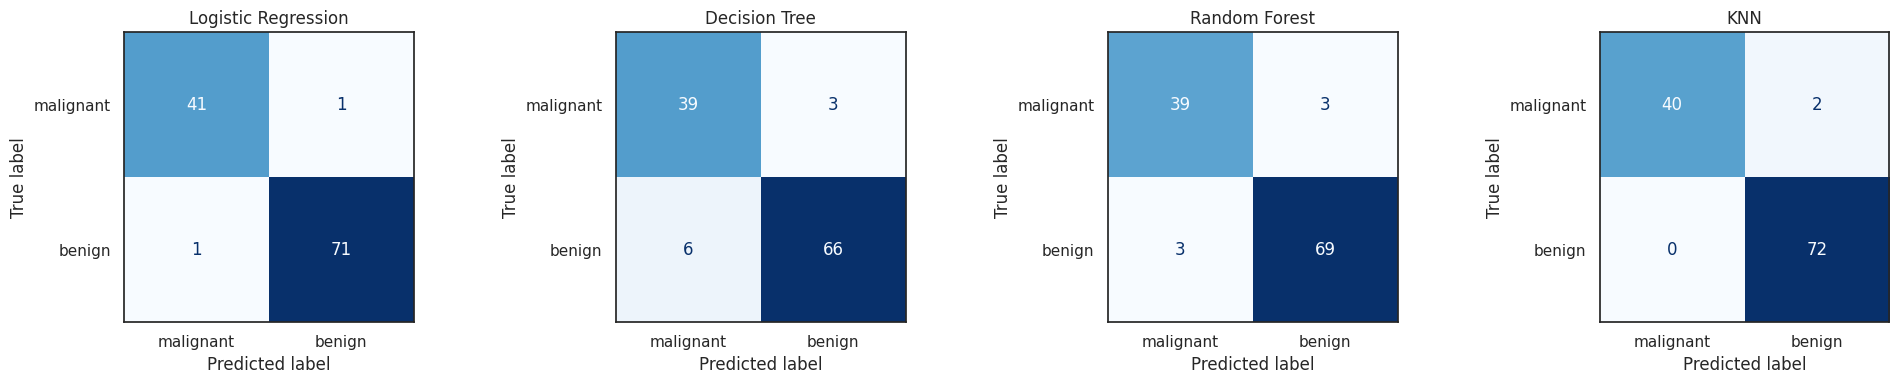

In [ ]:
# Matrizes de confusão de todos os modelos
fig, axes = plt.subplots(1, len(pipelines), figsize=(5 * len(pipelines), 4))
for ax, (name, pipe) in zip(axes, pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["malignant", "benign"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout()
plt.show()


In [ ]:
# Relatório de classificação detalhado do melhor modelo por recall
best_model_name = results_df["Recall (malignant)"].idxmax()
best_pipe = pipelines[best_model_name]
y_pred_best = best_pipe.predict(X_test)

print(f"Melhor modelo (por recall da classe maligna): {best_model_name}\n")
print(classification_report(y_test, y_pred_best, target_names=["malignant", "benign"]))


Melhor modelo (por recall da classe maligna): Logistic Regression

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



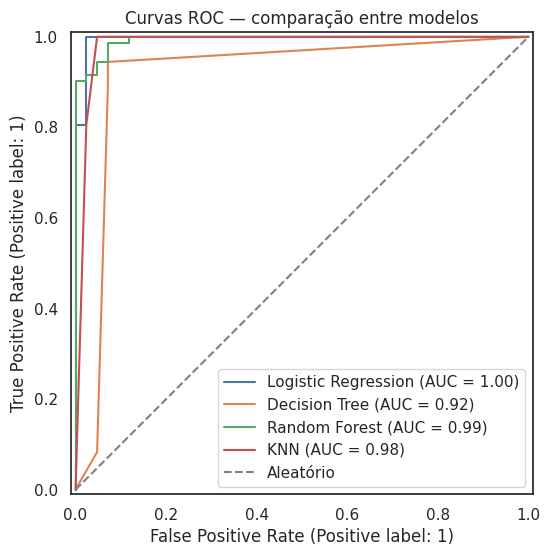

In [ ]:
# Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(7, 6))
for name, pipe in pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório")
ax.set_title("Curvas ROC — comparação entre modelos")
ax.legend()
plt.show()


<a name="explicabilidade"></a>
## 8. Explicabilidade (Feature Importance & SHAP)



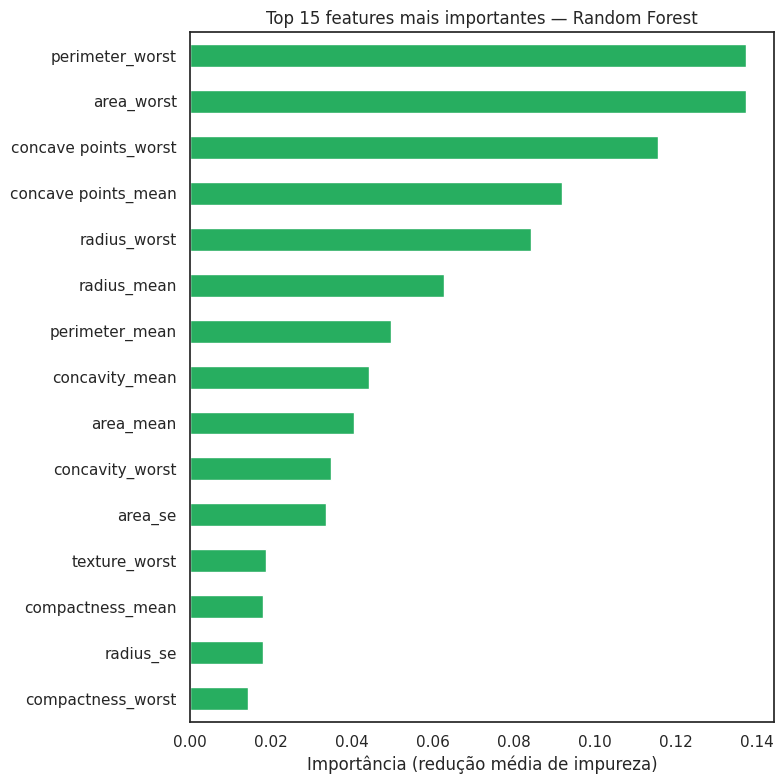

In [ ]:
# Feature importance nativa do Random Forest
rf_pipe = pipelines["Random Forest"]
rf_model = rf_pipe.named_steps["classifier"]

importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
importances.head(15).sort_values().plot(kind="barh", ax=ax, color="#27ae60")
ax.set_title("Top 15 features mais importantes — Random Forest")
ax.set_xlabel("Importância (redução média de impureza)")
plt.tight_layout()
plt.show()


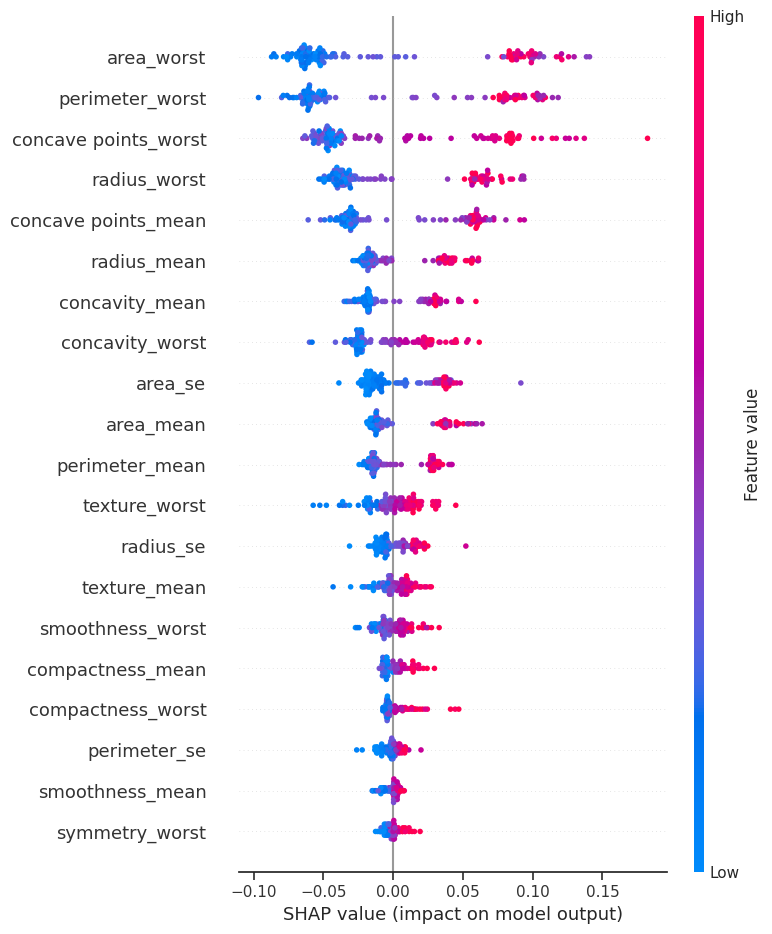

In [ ]:
import shap

# Explicação global e local via SHAP para o Random Forest
X_test_transformed = pd.DataFrame(
    rf_pipe.named_steps["preprocessor"].transform(X_test),
    columns=feature_cols,
    index=X_test.index,
)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_transformed)

# Para classificação binária, shap_values pode vir como lista [classe0, classe1] ou array 3D.
# Usamos o índice 0 porque rf_model.classes_ == [0, 1] e 0 = "malignant" (ver célula de carga
# dos dados) — o índice 1 corresponderia à classe "benign", invertendo a interpretação.
sv_malignant = shap_values[0] if isinstance(shap_values, list) else shap_values[:, :, 0]

shap.summary_plot(sv_malignant, X_test_transformed, show=True)
